# Import thư viện

In [ ]:
import pandas as pd
import matplotlib as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)

## Đọc dữ liệu từ file csv

In [2]:
df_ck = pd.read_csv('C:\\CS114\\ck-public.csv')
df_total = pd.read_csv('C:\\CS114\\annonimized.csv')

## Tổng quan về dữ liệu

In [3]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295198 entries, 0 to 295197
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   concat('it001',`assignment_id`)  295198 non-null  object
 1   concat('it001',`problem_id`)     295198 non-null  object
 2   concat('it001', username)        295198 non-null  object
 3   is_final                         295198 non-null  int64 
 4   status                           295198 non-null  object
 5   pre_score                        295198 non-null  int64 
 6   coefficient                      295198 non-null  int64 
 7   concat('it001',`language_id`)    295198 non-null  object
 8   created_at                       295198 non-null  object
 9   updated_at                       295198 non-null  object
 10  judgement                        295198 non-null  object
dtypes: int64(3), object(8)
memory usage: 24.8+ MB


In [4]:
df_ck.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hash    761 non-null    object 
 1   CK      755 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


### Chuyển cột điểm sang dạng số

In [5]:
df_ck['CK'] = pd.to_numeric(df_ck['CK'], errors='coerce')

### Ghép file annonimized và file điểm

In [6]:
df = pd.merge(df_total, df_ck, left_on="concat('it001', username)", right_on='hash', how='outer')

In [7]:
df['judgement'].unique()

array(['{"times":[0,0,0,0,0,0,0,0,0,0],"mems":[0,0,0,0,0,0,0,0,0,0],"verdicts":{"WRONG":10}}',
       '{"times":[0,0,0,0,0,0,0,0,0,0],"mems":[0,0,0,0,0,0,0,0,0,0],"verdicts":[]}',
       '{"times":[],"mems":[],"verdicts":{"\\n\\nIn function \'int main()\':\\n15:11: error: a function-definition is not allowed here before \'{\' token\\n":1}}',
       ...,
       '{"times":[0,0.53,0,0,0,0.53,0.51,0,0,0],"mems":[0,1984,0,0,0,1984,1984,0,0,0],"verdicts":{"Time Limit Exceeded":3}}',
       '{"times":[],"mems":[],"verdicts":{"\\n\\nIn function \'int main()\':\\n21:15: error: expected primary-expression before \'&gt;\' token\\n":1}}',
       '{"times":[],"mems":[],"verdicts":{"\\n\\nIn function \'PhanSo Nhap()\':\\n25:9: error: \'b\' was not declared in this scope\\n":1}}'],
      dtype=object)

### Xóa các đặc trưng không cần thiết

In [8]:
delete_columns = ['created_at', 'updated_at', 'hash']
df = df.drop(columns=delete_columns)

### WRONG VÀ TLE trong judgement

In [9]:
# valid_verdicts = set()

# for row in df_total['judgement'].dropna():
#     try:
#         data = json.loads(row)
#         verdicts = data.get('verdicts', {})
#         for key in verdicts.keys():
#             if ("error" not in key.lower()) and ('\n' not in key) and ('\\n' not in key):
#                 print(f"{key}: {verdicts[key]}")
#     except:
#         continue

# for verdict in sorted(valid_verdicts):
#     print(verdict)

### Lấy ra số testcase sai từ judgement

In [10]:
def extract_judgement_info(row):
    try:
        data = json.loads(row)
        times = data.get("times", [])
        mems = data.get("mems", [])
        verdicts = data.get("verdicts", {})

        avg_time = np.mean(times) if times else 0
        max_time = np.max(times) if times else 0

        avg_mem = np.mean(mems) if mems else 0
        max_mem = np.max(mems) if mems else 0

        n_wrong = verdicts.get("WRONG", 0)
        n_tle = verdicts.get("Time Limit Exceeded", 0)
        n_failed = n_wrong + n_tle

        return pd.Series([n_failed, avg_time, max_time, avg_mem, max_mem])
    except:
        return pd.Series([0, 0, 0, 0, 0])

In [11]:
df[['n_failed', 'avg_time', 'max_time', 'avg_mem', 'max_mem']] = df['judgement'].apply(extract_judgement_info)
df['n_failed'] = df['n_failed'].astype('Int64')
df.drop(columns=['judgement'], inplace=True)

df['code_runnable'] = (df['status'] == 'SCORE').astype(int)
df['compile_error'] = (df['status'] == 'Compilation Error').astype(int)
# df['syntax_error'] = (df['status'] == 'Syntax Error').astype(int)
# df['pending'] = (df['status'] == 'pending').astype(int)
df.drop(columns=['status'], inplace=True)

In [12]:
df.head(10)

,"concat('it001',`assignment_id`)","concat('it001',`problem_id`)","concat('it001', username)",is_final,pre_score,coefficient,"concat('it001',`language_id`)",CK,n_failed,avg_time,max_time,avg_mem,max_mem,code_runnable,compile_error
0,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
1,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,7a6e5ca470ff47c3b5048f240c4738de71010c78,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
2,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,de6d5fd28bed331063cc4930a0c0c1a6d3cad68c,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
3,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
4,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,7a6e5ca470ff47c3b5048f240c4738de71010c78,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
5,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,00b6dd4fc7eb817e03708c532016ef30ce564a61,1,10000,100,it0012,5.5,0,0.0,0.0,0.0,0.0,1,0
6,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,7a6e5ca470ff47c3b5048f240c4738de71010c78,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
7,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,7a6e5ca470ff47c3b5048f240c4738de71010c78,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
8,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,7a6e5ca470ff47c3b5048f240c4738de71010c78,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0
9,d0204dbfca44b08e0f01a0d9c70de22d7b270d91,7a6e5ca470ff47c3b5048f240c4738de71010c78,00b6dd4fc7eb817e03708c532016ef30ce564a61,0,0,100,it0012,5.5,10,0.0,0.0,0.0,0.0,1,0


In [13]:
df = df.groupby("concat('it001', username)").agg({
    "concat('it001',`assignment_id`)": pd.Series.nunique,
    "concat('it001',`problem_id`)": pd.Series.nunique,
    'pre_score': 'mean',
    # 'coefficient': 'mean',
    # "concat('it001',`language_id`)": pd.Series.nunique,
    'is_final': 'sum',
    'n_failed': 'sum',
    'avg_time': ['mean', 'max'],
    'avg_mem': ['mean', 'max'],
    'max_time': ['mean', 'max'],
    'max_mem': ['mean', 'max'],
    'code_runnable': 'sum',
    'compile_error': 'sum',
    # 'syntax_error': 'sum',
    # 'pending': 'sum',
    'CK': 'first',
})

df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns]

df = df.rename(columns={
    "concat('it001',`assignment_id`)_nunique": 'n_assignments',
    "concat('it001',`problem_id`)_nunique": 'n_problems',
    'pre_score_mean': 'pre_score',
    # 'coefficient_mean': 'coefficient',
    # "concat('it001',`language_id`)_nunique": 'n_languages',
    'is_final_sum': 'is_final',
    'n_failed_sum': 'n_failed',
    'avg_time_mean': 'mean(avg_time)',
    'avg_time_max': 'max(avg_time)',
    'avg_mem_mean': 'mean(avg_mem)',
    'avg_mem_max': 'max(avg_mem)',
    'max_time_mean': 'mean(max_time)',
    'max_time_max': 'max(max_time)',
    'max_mem_mean': 'mean(max_mem)',
    'max_mem_max': 'max(max_mem)',
    'code_runnable_sum': 'n_code_runnable',
    'compile_error_sum': 'n_compile_error',
    # 'syntax_error_sum': 'n_syntax_error',
    # 'pending_sum': 'n_pending',
    'CK_first': 'CK',
})

df = df.reset_index()

In [14]:
df.head()

,"concat('it001', username)",n_assignments,n_problems,pre_score,is_final,n_failed,mean(avg_time),max(avg_time),mean(avg_mem),max(avg_mem),mean(max_time),max(max_time),mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,CK
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,46,484,0.009621,0.510769,46.412758,1818.666667,0.025034,0.94,128.163265,2768.0,119,28,5.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,78,555,0.009392,0.606154,152.774253,1984.000000,0.017143,1.02,201.698842,2644.0,209,50,6.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,67,965,0.017642,0.524000,176.745897,10200.000000,0.052718,0.55,389.128205,10200.0,175,20,4.5
3,0134f9f410c65ad0e8c2254a7e9288670e02a183,4,47,5952.760000,47,174,0.005910,0.534000,23.808000,1984.000000,0.011200,0.55,59.520000,1984.0,76,24,NaN
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,66,260,0.031732,0.803571,186.571709,1785.600000,0.064766,1.06,259.588785,1984.0,94,13,5.0


### Chia tập train / test

In [15]:
df_final = df[df['CK'].notna()]

X = df_final.drop(columns=["concat('it001', username)", 'CK'])
y = df_final['CK']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

test_df = df[df['CK'].isna()]
X_test = test_df.drop(columns=["concat('it001', username)", 'CK'])

In [16]:
df_final

,"concat('it001', username)",n_assignments,n_problems,pre_score,is_final,n_failed,mean(avg_time),max(avg_time),mean(avg_mem),max(avg_mem),mean(max_time),max(max_time),mean(max_mem),max(max_mem),n_code_runnable,n_compile_error,CK
0,00b6dd4fc7eb817e03708c532016ef30ce564a61,7,46,5504.149660,46,484,0.009621,0.510769,46.412758,1818.666667,0.025034,0.94,128.163265,2768.0,119,28,5.5
1,00bef8afee8f3c595d535c9c03c490cac1a4f021,9,78,5488.552124,78,555,0.009392,0.606154,152.774253,1984.000000,0.017143,1.02,201.698842,2644.0,209,50,6.5
2,01122b3ef7e59b84189e65985305f575d6bdf83c,7,66,5973.753846,67,965,0.017642,0.524000,176.745897,10200.000000,0.052718,0.55,389.128205,10200.0,175,20,4.5
4,013de369c439ab0ead8aa7da64423aa395a8be39,8,52,6474.448598,66,260,0.031732,0.803571,186.571709,1785.600000,0.064766,1.06,259.588785,1984.0,94,13,5.0
5,014c59c6433fd764a0b08de6ffeb757eaf60aa73,9,90,5240.025126,90,528,0.000000,0.000000,30.906533,1984.000000,0.000000,0.00,39.879397,1984.0,154,45,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,840d07858c03f80f4695056e2cc7d0c474b83a25,6,43,5171.639640,44,249,0.001043,0.054000,18.895238,1700.571429,0.010721,0.54,53.621622,1984.0,81,30,5.5
797,844f5db2e7e31ae51eba025480679ed7e4708ac6,17,104,4785.224090,104,922,0.011511,0.606154,92.397501,10044.000000,0.016106,0.98,145.535014,10044.0,254,103,6.0
798,845acd04a77b3d1b623f255d9f9f8eae90892dab,8,52,4247.296774,53,505,0.002995,0.233333,53.409032,2128.000000,0.006710,0.52,64.929032,2128.0,117,38,6.0
799,8460eaaf887a6289fb156f7562fb739ba8e9629e,12,114,4278.605027,115,2019,0.009255,0.605000,155.850633,10044.000000,0.024327,0.94,412.193896,10044.0,416,141,7.0


### Huấn luyện

In [17]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Dự đoán và đánh giá trên tập kiểm định

In [18]:
y_pred_val = model.predict(X_val)
print("R^2 score trên tập kiểm định:", r2_score(y_val, y_pred_val))

R^2 score trên tập kiểm định: 0.2515260252264354


### Dự đoán kết quả trên tập test

In [19]:
test_df['CK'] = model.predict(X_test)

C:\Users\MrBeast\AppData\Local\Temp\ipykernel_8304\158634260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['CK'] = model.predict(X_test)


### Lưu kết quả điểm vào file csv để nộp

In [20]:
combined_df = pd.concat([
    df_final[["concat('it001', username)", 'CK']],
    test_df[["concat('it001', username)", 'CK']]
])

combined_df.to_csv('result.csv', index=False, header=False, encoding='utf-8')

### Lưu lại mô hình

In [21]:
joblib.dump(model, 'best_model.pkl')

['best_model.pkl']

### Các đặc trưng có ảnh hưởng đến dự đoán

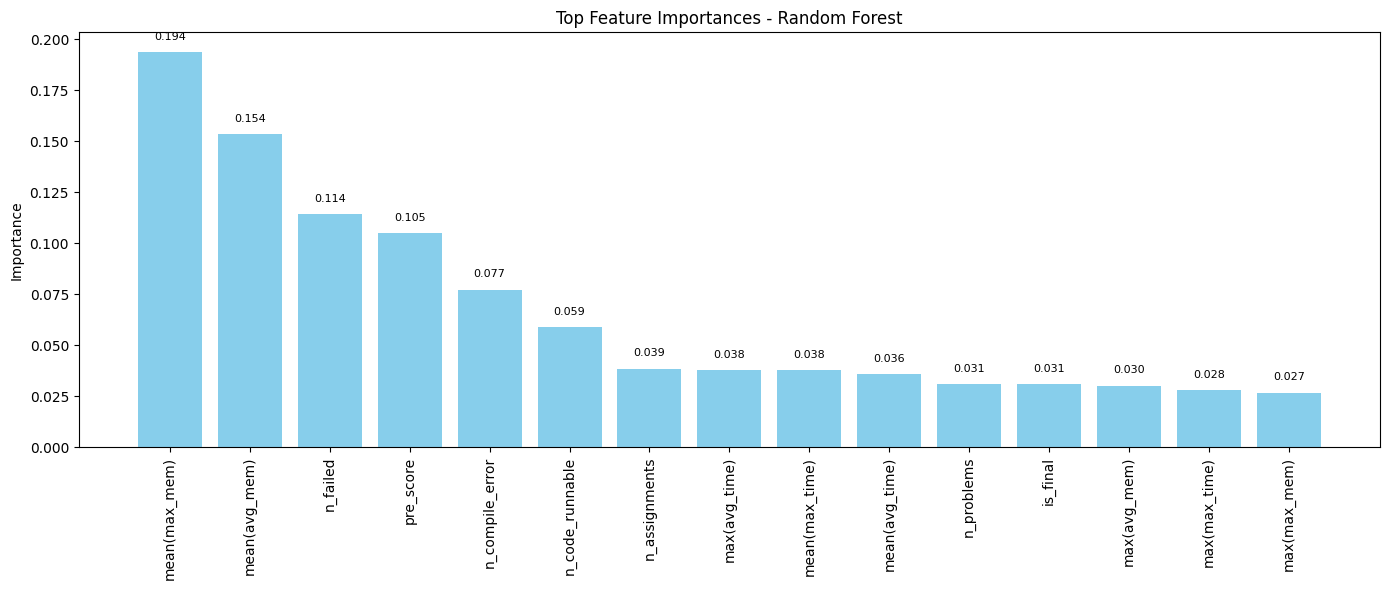

In [22]:
importances = model.feature_importances_
feature_names = X_train.columns 

indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = feature_names[indices]

top_k = min(20, len(importances))
sorted_importances = sorted_importances[:top_k]
sorted_features = sorted_features[:top_k]

# Vẽ
plt.figure(figsize=(14, 6))
bars = plt.bar(range(top_k), sorted_importances, color='skyblue', align='center')
plt.xticks(range(top_k), sorted_features, rotation=90)
plt.title('Top Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()

# Ghi nhãn số
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.005, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.show()
